In [1]:
!pip install opencv-python

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense

### Load DataSet

In [6]:
dataset_path = r'E:\Deep Learning\DL\1 Deep Learning Projects\CNN\Vehicle Image Classification\Vehicles'

### Loading and Splitting the Image Dataset

In [8]:
train_df = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels = 'inferred',
    label_mode = 'int',
    image_size = (256, 256),
    batch_size = 32,
    validation_split = 0.2,
    subset = 'training',
    seed = 42
)

test_df = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels = 'inferred',
    label_mode = 'int',
    image_size = (256, 256),
    batch_size = 32,
    validation_split = 0.2,
    subset = 'validation',
    seed = 42
)

Found 5588 files belonging to 7 classes.
Using 4471 files for training.
Found 5588 files belonging to 7 classes.
Using 1117 files for validation.


### Normalization

In [10]:
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_df = train_df.map(process)
test_df = test_df.map(process)

### CNN Archeticture

In [16]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3, 3), padding = 'valid', activation = 'relu',input_shape = (256, 256, 3)))
model.add(MaxPooling2D(pool_size = (3, 3), strides = 2, padding = 'valid'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(16, kernel_size = (3, 3), padding = 'valid', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (3, 3), strides = 2, padding = 'valid'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(32, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(16, activation = 'relu'))
model.add(Dropout(0.1))

# Output Layer
model.add(Dense(7, activation='softmax'))

In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 124, 124, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 61, 61, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 61, 61, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 59536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │     1,905,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,911,543 (7.29 MB)

 Trainable params: 1,911,447 (7.29 MB)

 Non-trainable params: 96 (384.00 B)

### Model Compilation

In [18]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

### Model Training

In [19]:
history = model.fit(train_df, epochs = 5, validation_data = test_df)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 463s 3s/step - accuracy: 0.3598 - loss: 3.1521 - val_accuracy: 0.1987 - val_loss: 3.5844
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 436s 3s/step - accuracy: 0.5162 - loss: 1.5670 - val_accuracy: 0.1576 - val_loss: 5.6507
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 734s 5s/step - accuracy: 0.5705 - loss: 1.3439 - val_accuracy: 0.3044 - val_loss: 2.7234
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 478s 3s/step - accuracy: 0.6659 - loss: 1.0731 - val_accuracy: 0.5452 - val_loss: 1.5863
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.7316 - loss: 0.8298 - val_accuracy: 0.6858 - val_loss: 1.1112


## Accuracy

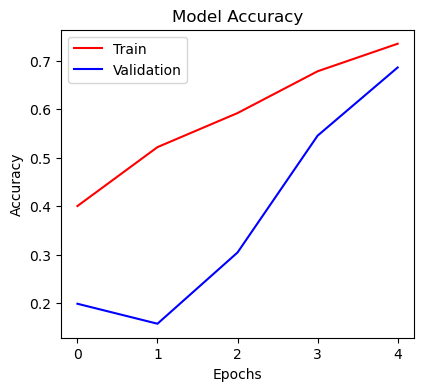

In [42]:
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='Train')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

## Loss

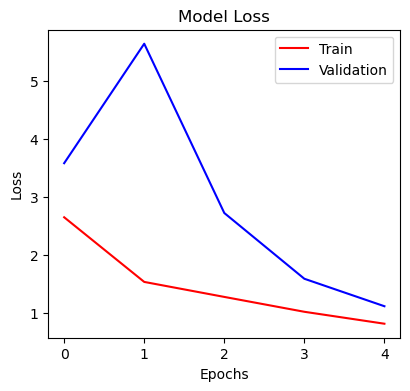

In [43]:
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='red', label='Train')
plt.plot(history.history['val_loss'], color='blue', label='Validation')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

## Model Prediction

In [59]:
img_path = r'E:\Deep Learning\DL\1 Deep Learning Projects\CNN\Vehicle Image Classification\Vehicles\Motorcycles\Motorcycle (22).jpg'

In [60]:
import cv2
test_img = cv2.imread(r'E:\Deep Learning\DL\1 Deep Learning Projects\CNN\Vehicle Image Classification\Vehicles\Motorcycles\Motorcycle (22).jpg')

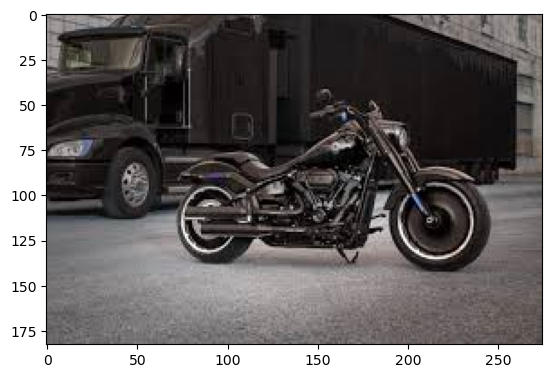

In [61]:
plt.imshow(test_img)

In [62]:
test_img.shape

(183, 275, 3)

In [63]:
test_img = cv2.resize(test_img, (255, 255))

In [64]:
test_input = cv2.resize(test_img, (256, 256)).reshape(1, 256, 256, 3)

In [65]:
class_names = [
    'Planes',
    'Bikes',
    'Cars',
    'Motorcycles',
    'Ships',
    'Trains'
]

In [66]:
prediction = model.predict(test_input)
predicted_class = np.argmax(prediction[0])

print("Predicted Class : ", class_names[predicted_class])
print("Confidence : ", prediction[0][predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
Predicted Class :  Motorcycles
Confidence :  0.17694242
